<a href="https://colab.research.google.com/github/Abhinav-DSA/Deep-Learning/blob/main/image_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow
import os

In [3]:
!pwd

/content


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data="/content/drive/MyDrive/data"


In [6]:
happy_path="/content/drive/MyDrive/data/happy"


In [7]:
sad_path="/content/drive/MyDrive/data/sad"

In [8]:
os.listdir(data)


['sad', 'happy']

In [9]:
image_class = 'happy'
os.path.join(data,image_class)


'/content/drive/MyDrive/data/happy'

In [10]:
image_exts = ['jpeg','jpg', 'bmp', 'png']

In [11]:
for image_class in os.listdir(data):
    for image in os.listdir(os.path.join(data, image_class)):
        image_path = os.path.join(data, image_class, image)
        try:
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts:
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e:
            print('Issue with image {}'.format(image_path))

Issue with image /content/drive/MyDrive/data/sad/image-20160914-4963-19knfh1.jpg
Issue with image /content/drive/MyDrive/data/sad/Crying-girl.jpg
Issue with image /content/drive/MyDrive/data/sad/maxresdefault2.jpg
Issue with image /content/drive/MyDrive/data/sad/maxresdefault3.jpg
Issue with image /content/drive/MyDrive/data/sad/fTw5aVC5_400x400.jpg
Issue with image /content/drive/MyDrive/data/sad/gettyimages-957787572.jpg
Issue with image /content/drive/MyDrive/data/sad/dark-depression-mood-people-wallpaper-preview.jpg
Issue with image /content/drive/MyDrive/data/sad/280-2804580_sad-people-png-sad-person-png-transparent-png.png
Issue with image /content/drive/MyDrive/data/sad/maxresdefault4.jpg
Issue with image /content/drive/MyDrive/data/sad/images10.jpg
Issue with image /content/drive/MyDrive/data/sad/iStock_000001932580XSmall.jpg
Issue with image /content/drive/MyDrive/data/sad/smiling-man-crowd-sad-people-vector-58533122.jpg
Issue with image /content/drive/MyDrive/data/sad/SAD.jpg

In [12]:
import tensorflow as tf

In [13]:
data = tf.keras.utils.image_dataset_from_directory(data)

Found 171 files belonging to 2 classes.


In [14]:
data_iterator=data.as_numpy_iterator


In [15]:
batch=data_iterator().next()


In [16]:
from matplotlib import pyplot as plt

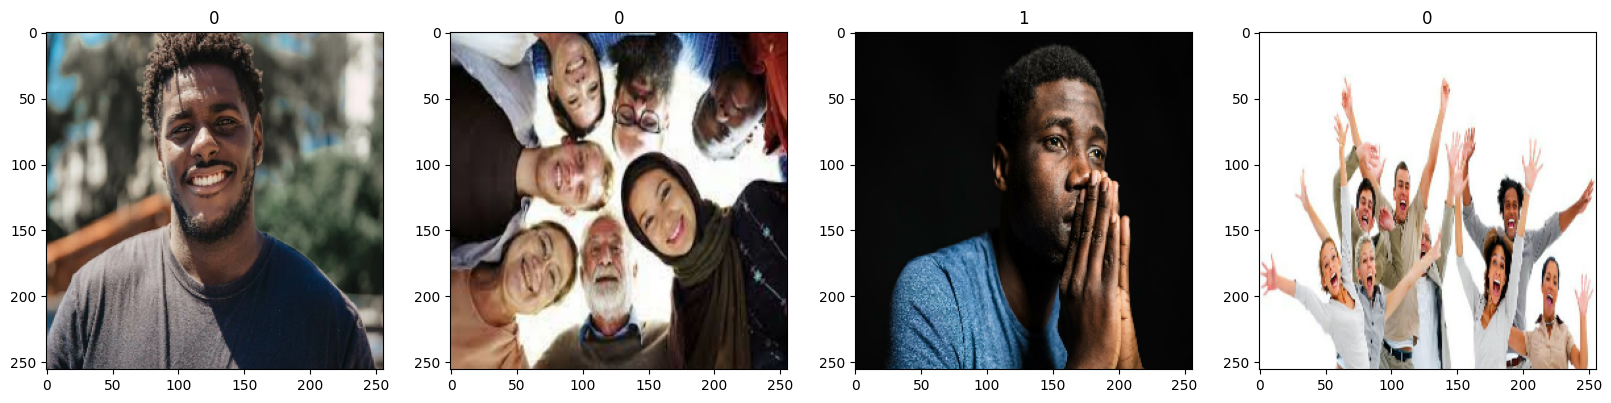

In [17]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

SCALING THE IMAGES


In [18]:
data=data.map(lambda x,y:(x/255,y))

In [19]:
scaled_images=data.as_numpy_iterator()

In [20]:
batch=scaled_images.next()

In [21]:
batch[0].min()

np.float32(0.0)

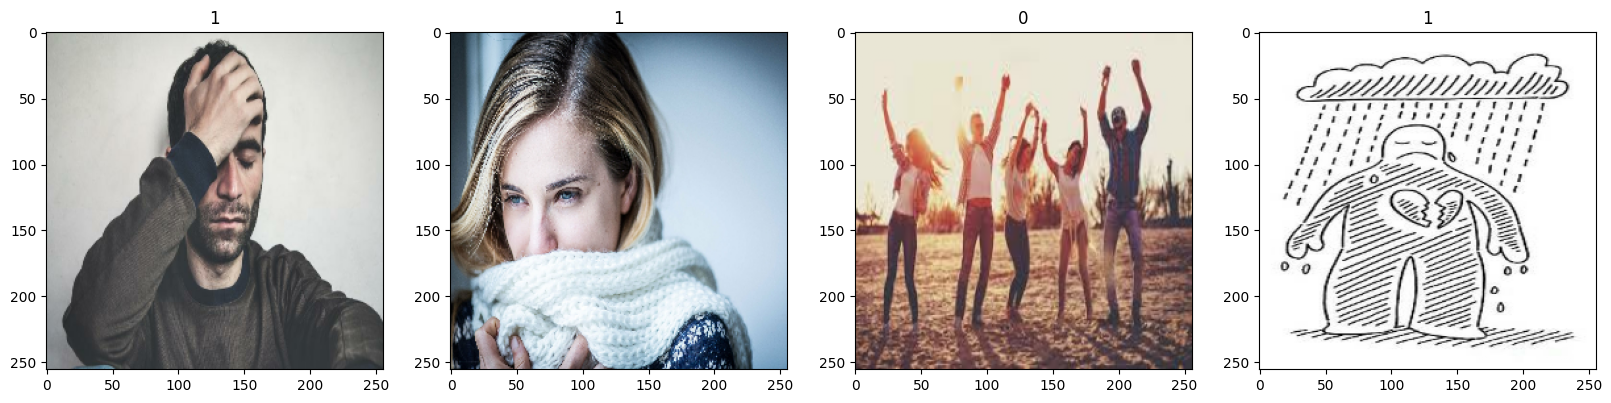

In [22]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])

In [23]:
len(data)

6

In [24]:
train_data=data.take(round(len(data)*.7))
val_data=data.skip(round(len(data)*.7)).take(round(len(data)*.2))
test_data=data.skip(round(len(data)*.9)).take(round(len(data)*.1))

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [27]:
model=Sequential()

In [28]:
model.add(Conv2D(16, (3,3), 1, activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D())
model.add(Conv2D(32, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(16, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

TRAINING STARTS


In [35]:
logdir='logs'

In [36]:

tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [39]:
hist = model.fit(train_data, epochs=20, validation_data=val_data, callbacks=[tensorboard_callback])

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step - accuracy: 0.5703 - loss: 0.8527 - val_accuracy: 0.4688 - val_loss: 0.7042
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.5469 - loss: 0.6764 - val_accuracy: 0.7188 - val_loss: 0.5609
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.6094 - loss: 0.5614 - val_accuracy: 0.7500 - val_loss: 0.4142
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.7500 - loss: 0.5072 - val_accuracy: 0.8438 - val_loss: 0.4672
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.7812 - loss: 0.4619 - val_accuracy: 0.8438 - val_loss: 0.3736
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.8750 - loss: 0.3441 - val_accuracy: 0.9375 - val_loss: 0.2340
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.9062 - loss: 0.2730 - val_accuracy: 0.9688 - val_loss: 0.1772
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.9531 - loss: 0.2036 - val_accuracy: 1.0000 - val_loss: 0.1165
Epoch 9/

In [47]:
import cv2
import numpy as np
from matplotlib import pyplot as plt


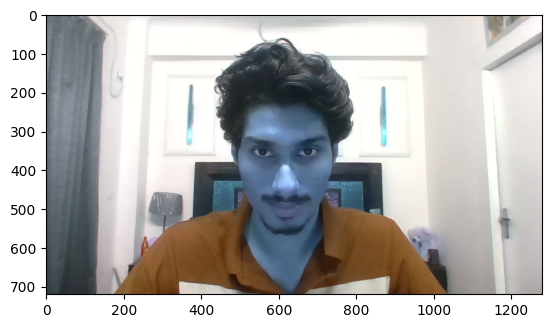

In [44]:
img = cv2.imread('WIN_20260714_19_02_35_Pro.jpg')
plt.imshow(img)
plt.show()

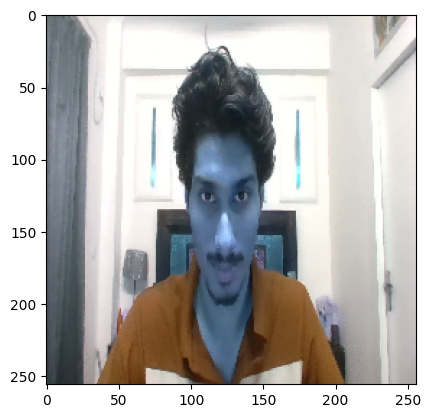

In [45]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [48]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


In [49]:
yhat

array([[0.98161864]], dtype=float32)